# ML - Iris Classification

This project was undertaken as an introductory study to develop a foundational understanding of Machine Learning concepts and methodologies, including exploratory data analysis, data preprocessing, feature engineering, feature scaling, and model development.

## Objective 

This notebook aims to develop a supervised machine learning model to classify Iris flowers into three species: 
- Iris setosa
- Iris versicolor
- Iris virginica

The classification is based on four features: sepal length, sepal width, petal length, and petal width.

# Exploratory Data Analysis and Feature Selection

This notebook focuses on exploring and analyzing the Iris dataset in order to better understand its structure, distributions, and relationships between variables.

The main objectives are to:

- Load and inspect the dataset
- Explore and analyze the data
- Identify relevant patterns and observations
- Select the most informative features for the classification task


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from matplotlib.colors import LinearSegmentedColormap

sb.set_theme(style="whitegrid")

In [50]:
df = pd.read_csv("data/iris.csv", sep=",", decimal=".")
df.columns = df.columns.str.strip()

if "Id" in df.columns:
    df = df.drop(columns=["Id"])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [51]:
df.info()
print(f"Number of observations: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB
Number of observations: 150
Number of columns: 5


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [52]:
features = df.select_dtypes(include=np.number).columns.tolist()

print("Descriptive statistics:")
display(df[features].describe())

print("Species distribution:")
display(df["Species"].value_counts())

print("Species distribution (%):")
display(
    df["Species"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Mean feature values by species:")
display(
    df.groupby("Species")[features]
    .mean()
    .round(2)
)

Descriptive statistics:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Species distribution:


Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Species distribution (%):


Species
Iris-setosa        33.33
Iris-versicolor    33.33
Iris-virginica     33.33
Name: proportion, dtype: float64

Mean feature values by species:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.01,3.42,1.46,0.24
Iris-versicolor,5.94,2.77,4.26,1.33
Iris-virginica,6.59,2.97,5.55,2.03


<Figure size 600x600 with 0 Axes>

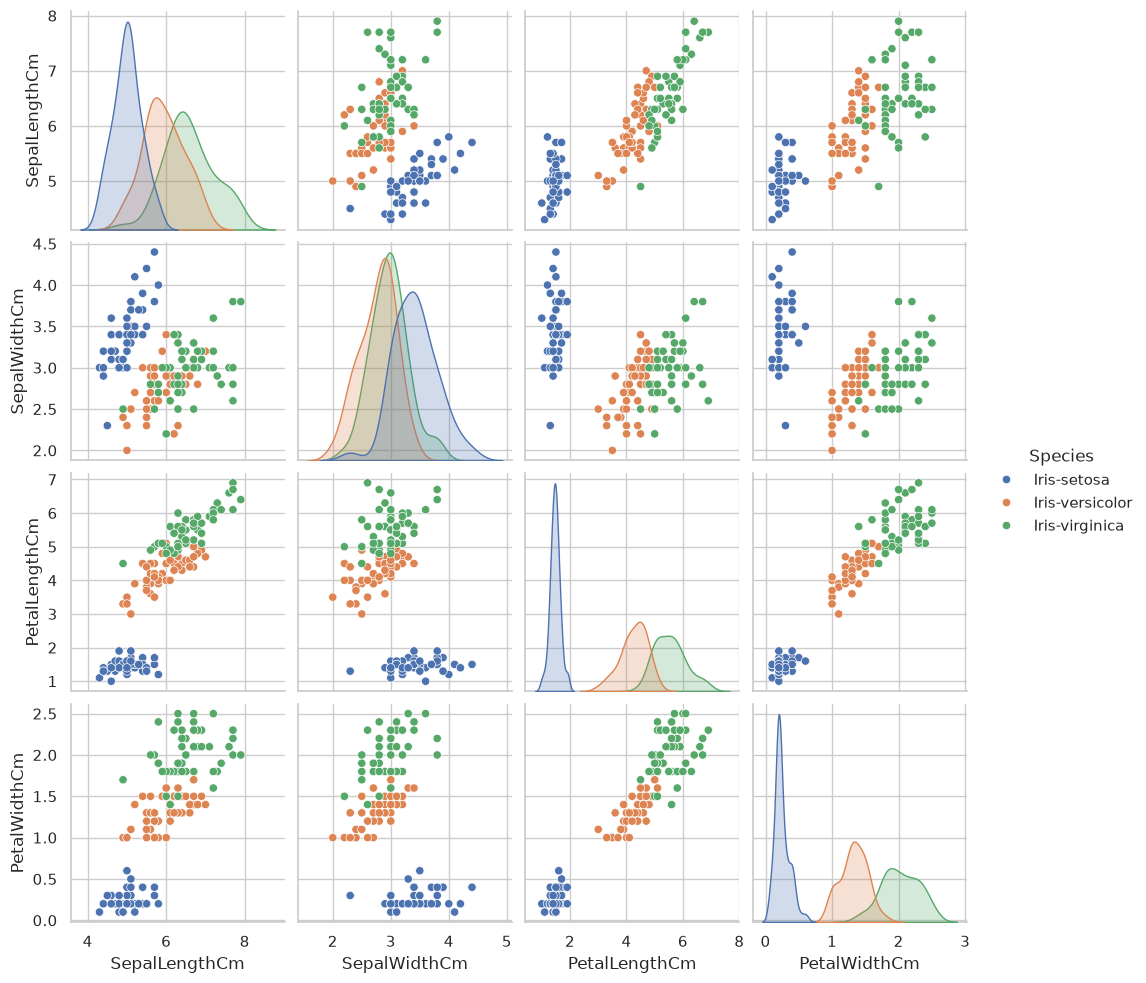

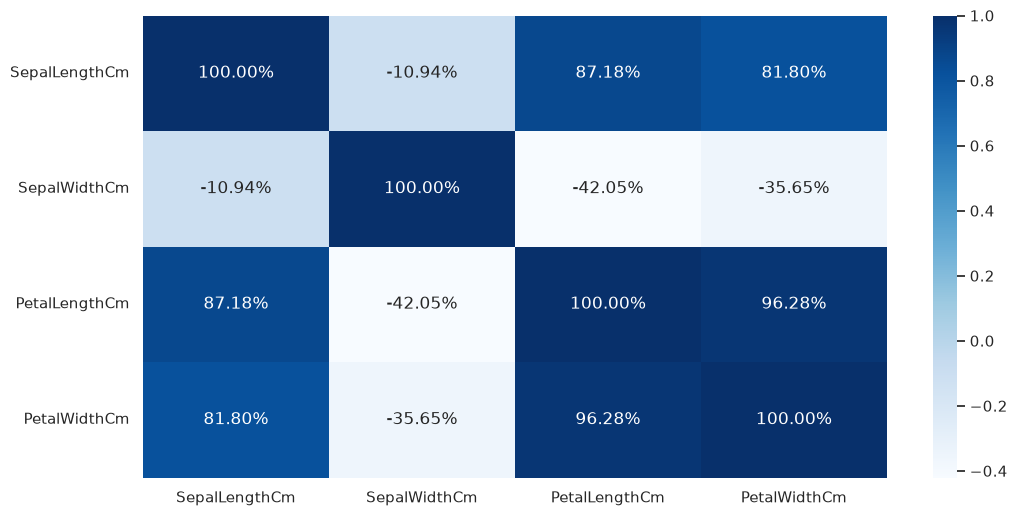

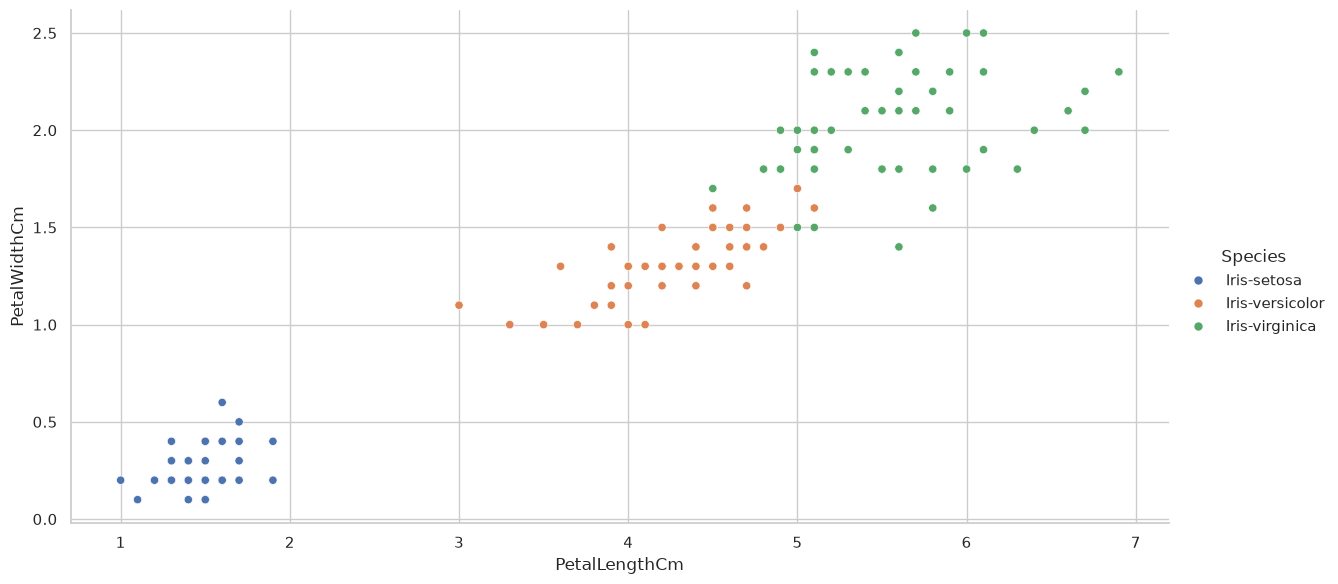

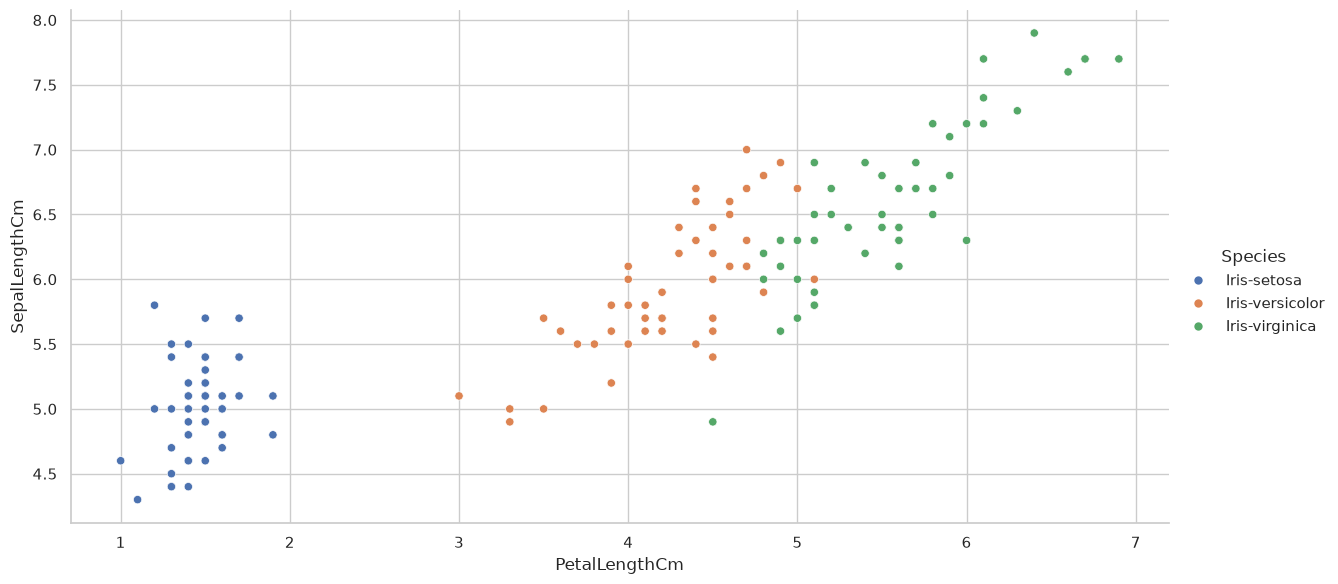

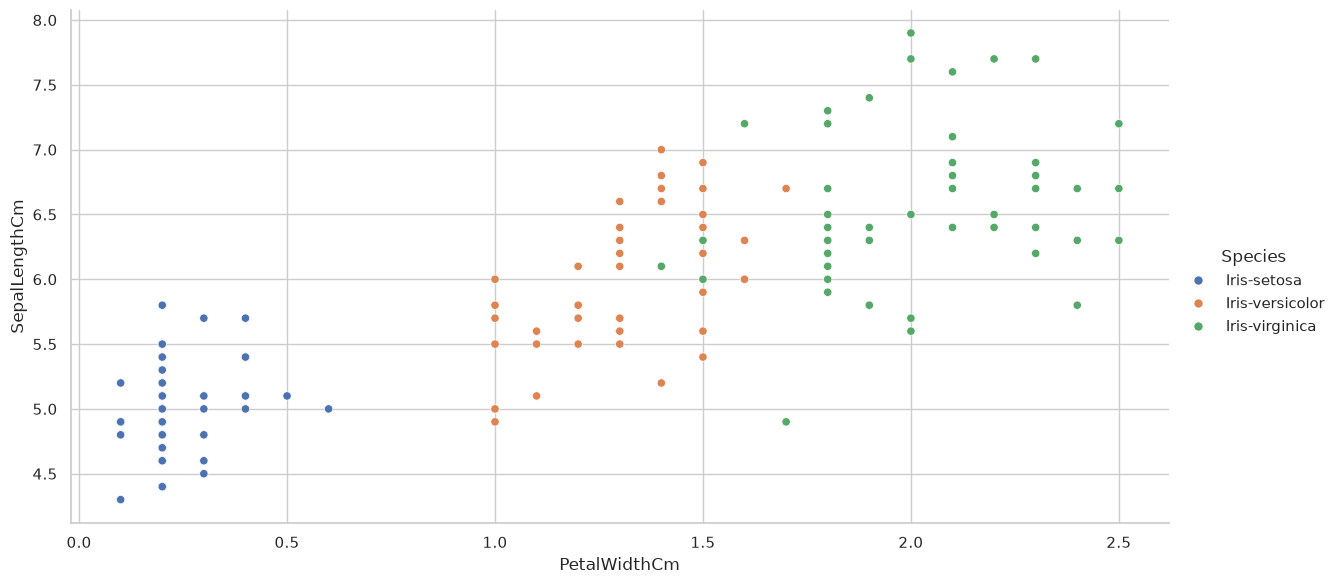

In [53]:
plt.figure(figsize=(6, 6))

sb.pairplot(
    data=df,
    vars=features,
    hue="Species"
)

plt.show()

features_correlation = df[features].corr()

plt.figure(figsize=(12, 6))

sb.heatmap(
    data=features_correlation,
    annot=True,
    fmt=".2%",
    cmap="Blues"
    
)

plt.show()

sb.relplot(
    x="PetalLengthCm",
    y="PetalWidthCm",
    data=df,
    hue="Species",
    aspect=2,
    height=6
)

plt.show()

sb.relplot(
    x="PetalLengthCm",
    y="SepalLengthCm",
    data=df,
    hue="Species",
    aspect=2,
    height=6
)

plt.show()

sb.relplot(
    x="PetalWidthCm",
    y="SepalLengthCm",
    data=df,
    hue="Species",
    aspect=2,
    height=6
)

plt.show()

In [54]:
df.groupby("Species")[features].agg(["mean", "std"])

X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

y = df["Species"]

X_petal = df[
    [
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

In [55]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

The dataset is partitioned into training and testing subsets to ensure an objective evaluation of model performance.
The training subset is used for model fitting, while the testing subset is reserved exclusively for performance assessment.
A stratified split is applied to preserve the original class distribution across both subsets.
This procedure provides a more reliable estimate of the model’s generalization capability.

In [56]:
X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]

y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


The target variable consists of categorical class labels corresponding to the three Iris species.
These labels are transformed into numerical representations using label encoding.
This transformation enables their direct use within machine learning algorithms that require numerical target values.
The encoding scheme is fitted on the training labels and consistently applied to the testing labels.

In [57]:
encoder = LabelEncoder()

y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

print("Classes:", encoder.classes_)
print("Encoded classes:", encoder.transform(encoder.classes_))

Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded classes: [0 1 2]


Feature standardization is performed using the StandardScaler transformation.
Each numerical variable is rescaled to have approximately zero mean and unit variance.
The scaler is fitted exclusively on the training data in order to prevent information leakage from the testing set.
The learned transformation is subsequently applied to the testing features to ensure methodological consistency.

In [58]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

display(X_train_scaled.head())

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
8,-1.721568,-0.324840,-1.347036,-1.320168
106,-1.124492,-1.226129,0.414290,0.651867
76,1.144395,-0.550162,0.584741,0.257460
9,-1.124492,0.125805,-1.290219,-1.451638
89,-0.408002,-1.226129,0.130206,0.125991


X_train_scaled shape: (120, 4)
X_test_scaled shape: (30, 4)


In [59]:
import joblib

prepared_data = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train_encoded": y_train_encoded,
    "y_test_encoded": y_test_encoded,
    "X_train_scaled": X_train_scaled,
    "X_test_scaled": X_test_scaled,
    "encoder": encoder,
    "scaler": scaler
}

joblib.dump(prepared_data, "data/iris_prepared.pkl")

['data/iris_prepared.pkl']